In [29]:
import glob, sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

thismodule = sys.modules[__name__]


In [ ]:
data_path = '/home/bfildier/analyses/FildierSaba2026/input/sensitivity_analysis'

In [24]:
! ls /home/bfildier/analyses/FildierSaba2026/input/sensitivity_analysis

delta_t_enriched.csv	 lambda_min_enriched.csv  Tbmin_enriched.csv
lambda_max_enriched.csv  sigma_enriched.csv


In [31]:
varids = 'Tbmin', 'lambda_min', 'sigma', 'lambda_max', 'delta_t'

for varid in varids:

    file_name = '%s_enriched.csv'%varid
    setattr(thismodule,'data_%s'%varid,pd.read_csv(os.path.join(data_path,file_name)))

In [33]:
data_Tbmin

,case_id,sigma_km,lambda_min_km,lambda_max_km,Tb_seed_K,Tb_anvil_K,delta_t_h,v_ref_kmh,n_cc,n_cc_final,...,final_Amax_homogeneity,fraction_after_initialization,IH25_75,Amax_homogeneity_25_75,final_IH25_75,final_Amax_homogeneity_25_75,INIT_IH25_75,INIT_Amax_homogeneity_25_75,initial_IH25_75,initial_Amax_homogeneity_25_75
0,C1,20.0,100.0,1500.0,210.0,235.0,3.0,15.0,38,38,...,0.995948,0.736842,0.987197,0.987197,0.987197,0.987197,0.512878,0.512878,0.512878,0.512878
1,C1,20.0,100.0,1500.0,211.0,235.0,3.0,15.0,42,42,...,0.996960,0.761905,0.982089,0.982089,0.982089,0.982089,0.514035,0.514035,0.514035,0.514035
2,C1,20.0,100.0,1500.0,212.0,235.0,3.0,15.0,41,41,...,0.997085,0.707317,0.978467,0.978467,0.978467,0.978467,0.667991,0.667991,0.667991,0.667991
3,C1,20.0,100.0,1500.0,213.0,235.0,3.0,15.0,41,41,...,0.995602,0.707317,0.983444,0.983444,0.983444,0.983444,0.614565,0.614565,0.614565,0.614565
4,C1,20.0,100.0,1500.0,214.0,235.0,3.0,15.0,41,41,...,0.996904,0.658537,0.982685,0.982685,0.982685,0.982685,0.600640,0.600640,0.600640,0.600640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,C9,20.0,100.0,1500.0,221.0,235.0,3.0,15.0,10,10,...,0.844118,0.100000,0.640691,0.640691,0.640691,0.640691,0.726446,0.726446,0.726446,0.726446
412,C9,20.0,100.0,1500.0,222.0,235.0,3.0,15.0,11,11,...,0.981691,0.181818,0.655467,0.655467,0.655467,0.655467,0.530497,0.530497,0.530497,0.530497
413,C9,20.0,100.0,1500.0,223.0,235.0,3.0,15.0,11,11,...,0.995923,0.272727,0.829788,0.829788,0.829788,0.829788,0.625085,0.625085,0.625085,0.625085
414,C9,20.0,100.0,1500.0,224.0,235.0,3.0,15.0,11,11,...,0.995923,0.272727,0.829892,0.829892,0.829892,0.829892,0.622516,0.622516,0.622516,0.622516


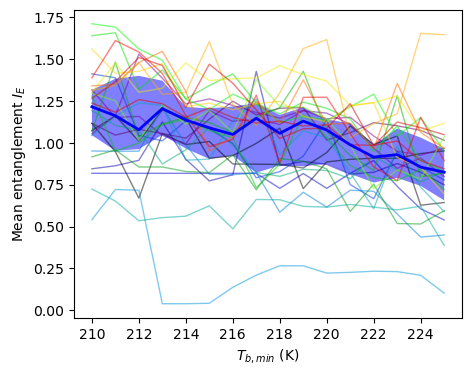

In [157]:
IE_name = 'IE3'
IA_name = 'IA7'
data = data_Tbmin

N_c = 27
N_Tb = len(data[data['case_id'] == 'C1']['Tb_seed_K'])

cmap = plt.get_cmap('nipy_spectral')
norm = plt.Normalize(1, N_c+1)

x_parameter = 'Tb_seed_K'
xlabel = r'$T_{b,min}$ (K)'

y_diagnostic = 'IE7'
ylabel = r'Mean entanglement $I_E$'

def subplotAllData(ax,data,x_parameter,xlabel,y_diagnostic,ylabel,y_denominator=None,
                   y_denominator_mean=None,
                   col_diag='k',col_ylabel='k',one_minus=False,exp_transform=False,yscale='linear',
                   show_all_cases=True,**kwargs):
    
    x = data[data['case_id'] == 'C1'][x_parameter]
    N_param = len(x)
    y_all = np.full((N_c,N_param),np.nan)
    
    # Show all cases
    for i_c in range(N_c):
        c_name = 'C%d'%(i_c+1)
        c_data = data[data['case_id'] == c_name]

        if y_denominator is None:
            y = np.array(c_data[y_diagnostic])
        elif y_denominator_mean is None:
            y = np.array(c_data[y_diagnostic])/np.array(c_data[y_denominator])
        else:
            y = np.array(c_data[y_diagnostic])/(np.array(c_data[y_denominator])+np.array(c_data[y_denominator_mean])*2)

        if one_minus:
            y = 1-y
        elif exp_transform:
            y = 1-np.exp(1-y)
            
        if len(y)>0:
            y_all[i_c] = y

            if show_all_cases:
                ax.plot(x,y,c=cmap(norm(i_c)),linewidth=1,alpha=0.5,*kwargs)
    
    y_25 = np.nanpercentile(y_all,25,axis=0)
    y_50 = np.nanpercentile(y_all,50,axis=0)
    y_75 = np.nanpercentile(y_all,75,axis=0)
    
    # Show median and interquartile
    ax.fill_between(x,y_25,y_75,color=col_diag,alpha=0.5,edgecolor=None)
    ax.plot(x,y_50,col_diag,linewidth=2,alpha=1,*kwargs)

    # Labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel,c=col_ylabel)

    # yscale
    ax.set_yscale(yscale)

    
    

fig,ax = plt.subplots(figsize=(5,4))

subplotAllData(ax,data,x_parameter,xlabel,y_diagnostic,ylabel,col_diag='blue')

1594.1599531250008


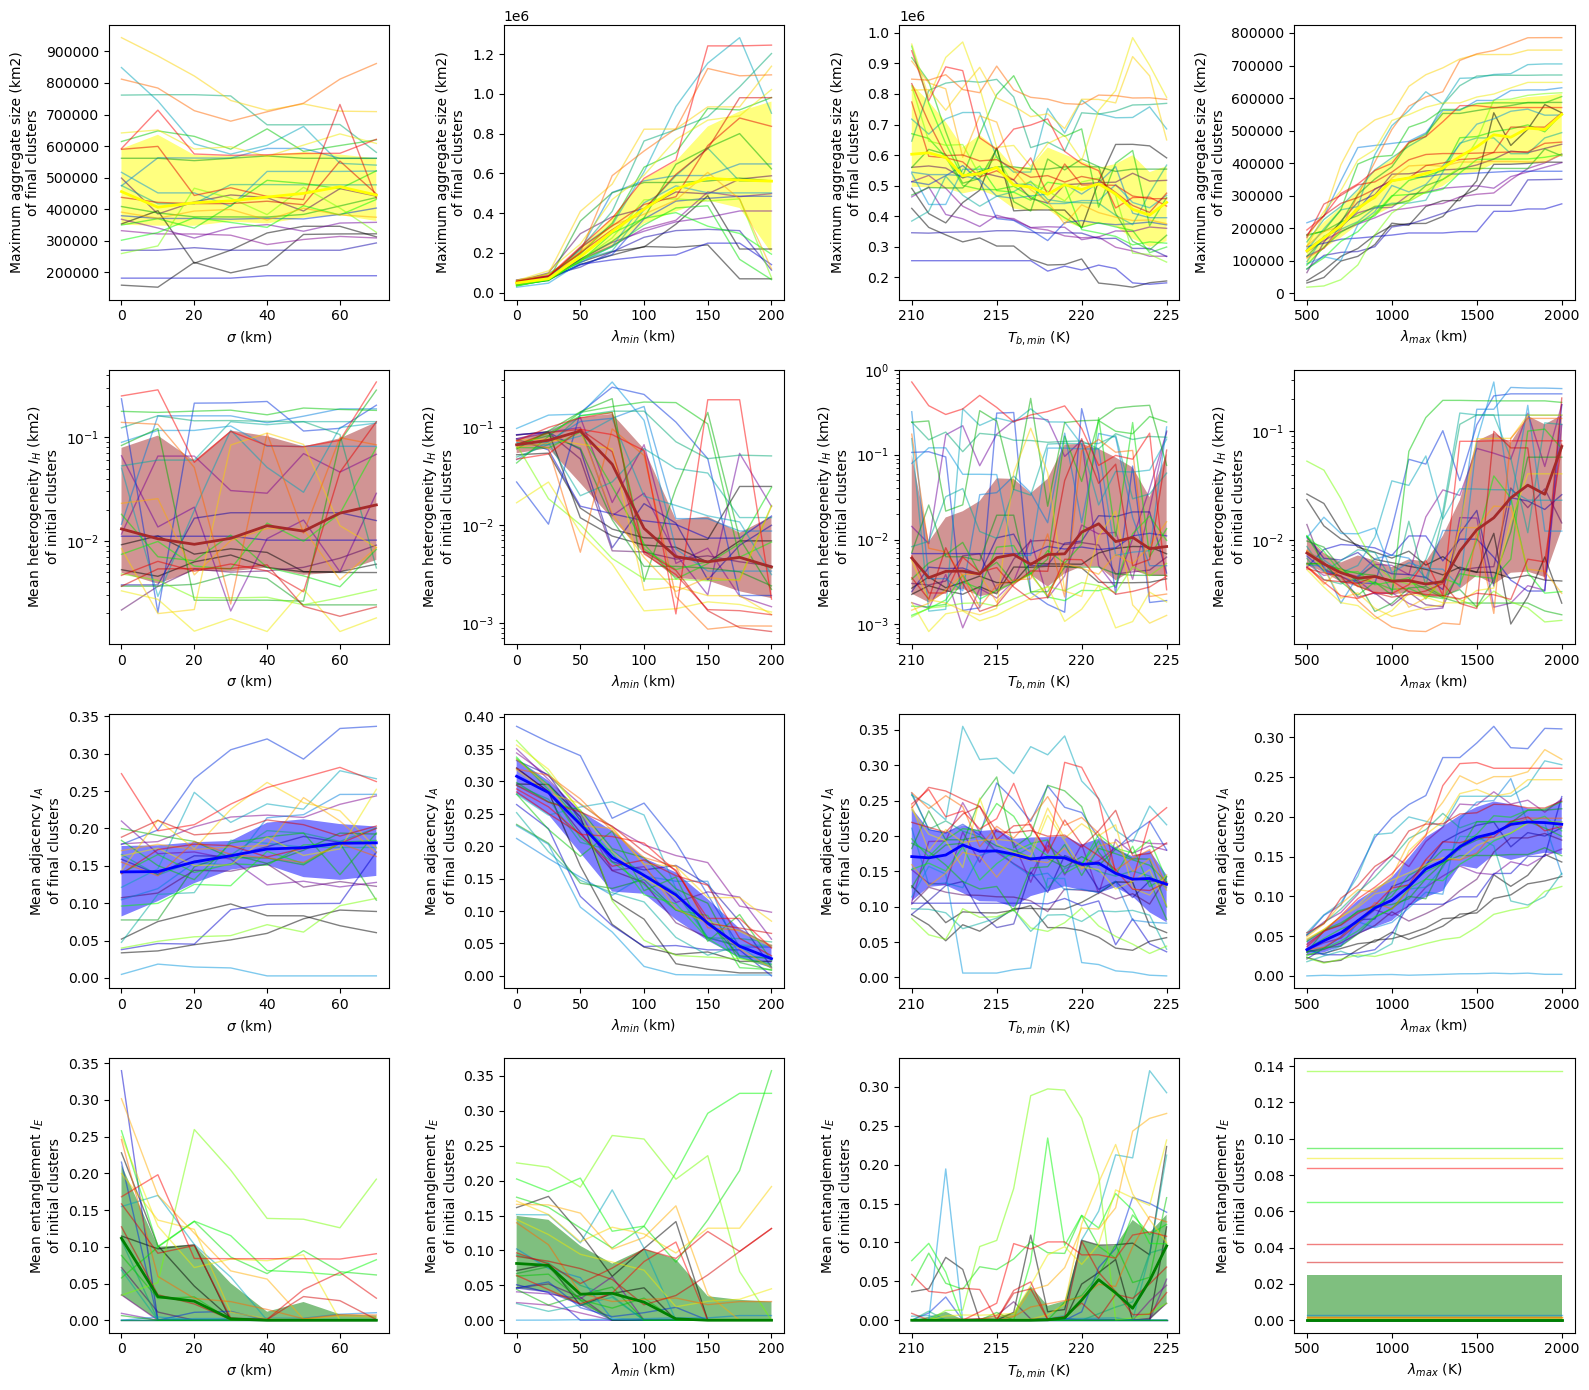

In [37]:
fig,axs = plt.subplots(4,4,figsize=(16,14))



#-- Row 1 - Maximum size
i_row = 0
diag = 'Amax_p90_km2'
label_diag = r"Maximum aggregate size (km2)" "\n" "of final clusters"
color_diag = 'yellow'

# Maximum size vs. sigma
ax = axs[i_row,0]
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','final_p90_cluster_size_km2',
               label_diag,col_diag=color_diag,yscale='linear')
# Maximum size vs. lambda_min
ax = axs[i_row,1]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)',diag,
               label_diag,col_diag=color_diag,yscale='linear')

# Maximum size vs. Tb_min
ax = axs[i_row,2]
subplotAllData(ax,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)',diag,
               label_diag,col_diag=color_diag,yscale='linear')

# Maximum size vs. lambda_max
ax = axs[i_row,3]
subplotAllData(ax,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (km)',diag,
               label_diag,col_diag=color_diag,yscale='linear')

#-- Row 2 - Heterogeneity
i_row += 1
diag = 'Amax_p90_minus_p10_km2'
diag_normalize = 'Amax_p90_km2'
label_diag = r"Mean heterogeneity $I_H$ (km2)" "\n" "of initial clusters"
color_diag = 'brown'

# Heterogeneity vs. sigma
ax = axs[i_row,0]
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','final_Amax_p90_minus_p10_km2',
               label_diag,y_denominator='final_Amax_p90_km2',col_diag=color_diag,
               one_minus=True,yscale='log')

# Heterogeneity vs. lambda_min
ax = axs[i_row,1]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)',diag,
               label_diag,y_denominator=diag_normalize,col_diag=color_diag,
               one_minus=True,yscale='log')

# Heterogeneity vs. Tb_min
ax = axs[i_row,2]
subplotAllData(ax,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)',diag,
               label_diag,y_denominator=diag_normalize,col_diag=color_diag,
               one_minus=True,yscale='log')

# Heterogeneity vs. lambda_max
ax = axs[i_row,3]
subplotAllData(ax,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (km)',diag,
               label_diag,y_denominator=diag_normalize,col_diag=color_diag,
               one_minus=True,yscale='log')

#-- Row 3 - Adjacency
i_row += 1

# Adjacency vs. sigma
ax = axs[i_row,0]
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','IA5',r"Mean adjacency $I_A$" "\n" "of final clusters",col_diag='blue')

# Adjacency vs. lambda_min
ax = axs[i_row,1]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','IA5',r"Mean adjacency $I_A$" "\n" "of final clusters",col_diag='blue')

# Adjacency vs. Tb_min
ax = axs[i_row,2]
subplotAllData(ax,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)','IA5',r"Mean adjacency $I_A$" "\n" "of final clusters",col_diag='blue')

# Adjacency vs. lambda_max
ax = axs[i_row,3]
subplotAllData(ax,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (km)','IA5',r"Mean adjacency $I_A$" "\n" "of final clusters",col_diag='blue')


#-- Row 4 - Entanglement
i_row += 1

# Entanglement vs. sigma
ax = axs[i_row,0]
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','INIT_IE5',r"Mean entanglement $I_E$" "\n" "of initial clusters",col_diag='green')

# Entanglement vs. lambda_min
ax = axs[i_row,1]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','INIT_IE5',r"Mean entanglement $I_E$" "\n" "of initial clusters",col_diag='green')

# Entanglement vs. Tb_min
ax = axs[i_row,2]
subplotAllData(ax,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)','INIT_IE5',r"Mean entanglement $I_E$" "\n" "of initial clusters",col_diag='green')

# Entanglement vs. lambda_max
ax = axs[i_row,3]
subplotAllData(ax,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (K)','INIT_IE5',r"Mean entanglement $I_E$" "\n" "of initial clusters",col_diag='green')


plt.tight_layout()


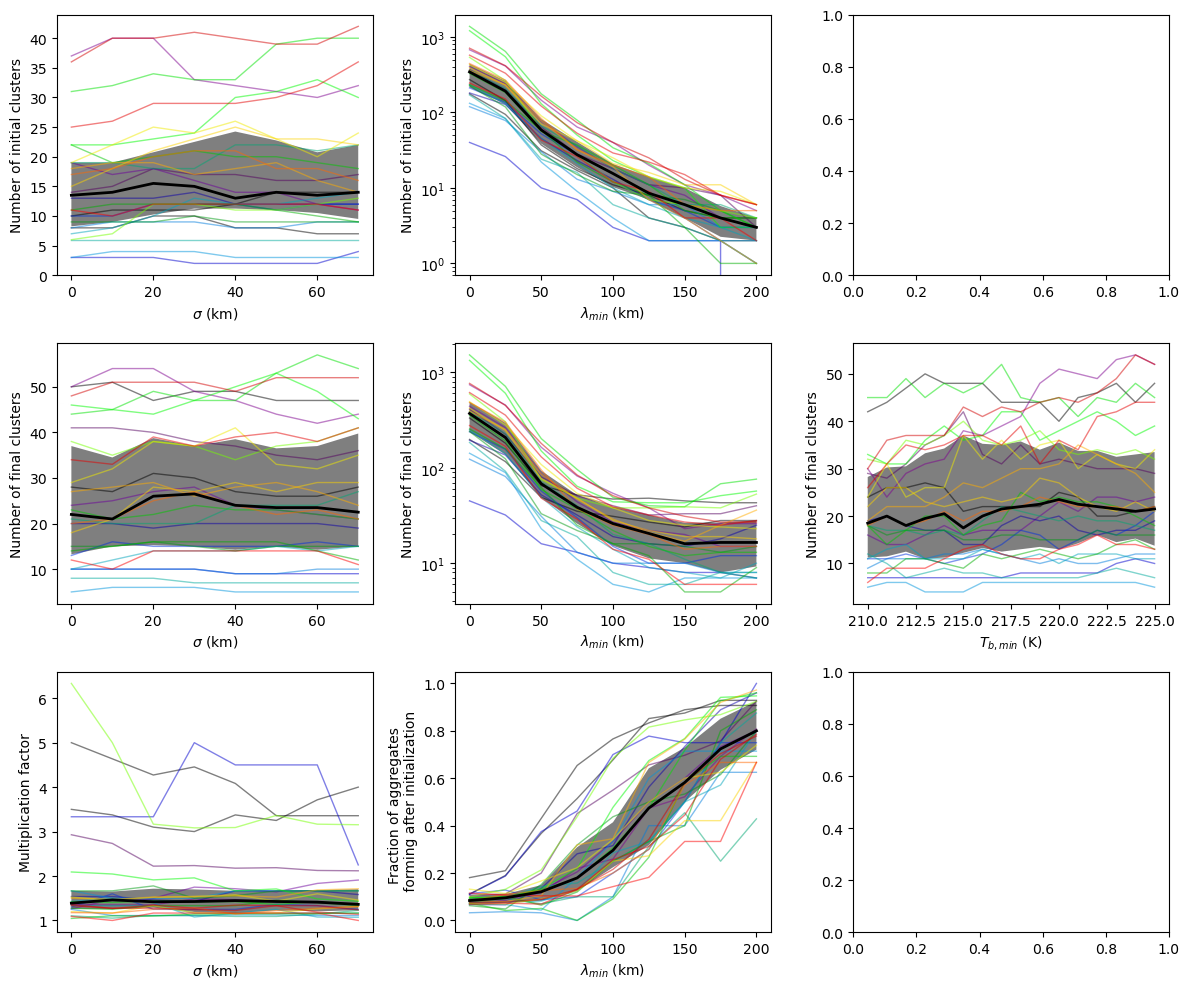

In [155]:
fig,axs = plt.subplots(3,3,figsize=(12,10))

# n_cc_init vs. sigma
ax = axs[0,0]
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','n_initial_clusters',"Number of initial clusters")

# n_cc_init vs. lambda_min
ax = axs[0,1]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_initial_clusters',"Number of initial clusters",
              yscale='log')

# n_cc_init vs. Tb_min
ax = axs[0,2]

# n_cc_final vs. sigma
ax = axs[1,0]
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','final_n_cc',"Number of final clusters")

# n_cc_final vs. lambda_min
ax = axs[1,1]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_final_clusters',"Number of final clusters",
              yscale='log')

# n_cc_final vs. Tb_min
ax = axs[1,2]
subplotAllData(ax,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)','n_cc',"Number of final clusters")

# n_cc_final/n_cc_init vs. sigma
ax = axs[2,0]
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','final_n_cc',"Multiplication factor",y_denominator='n_initial_clusters')

# n_cc_final/n_cc_init vs. lambda_min
ax = axs[2,1]
# subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_final_clusters',"Multiplication factor",y_denominator='n_initial_clusters',
#               yscale='log')
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_initial_clusters',"Fraction of aggregates \n forming after initialization",y_denominator='n_final_clusters',
              one_minus=True,yscale='linear')

# n_cc_final/n_cc_init vs. Tb_min
ax = axs[2,2]

plt.tight_layout()


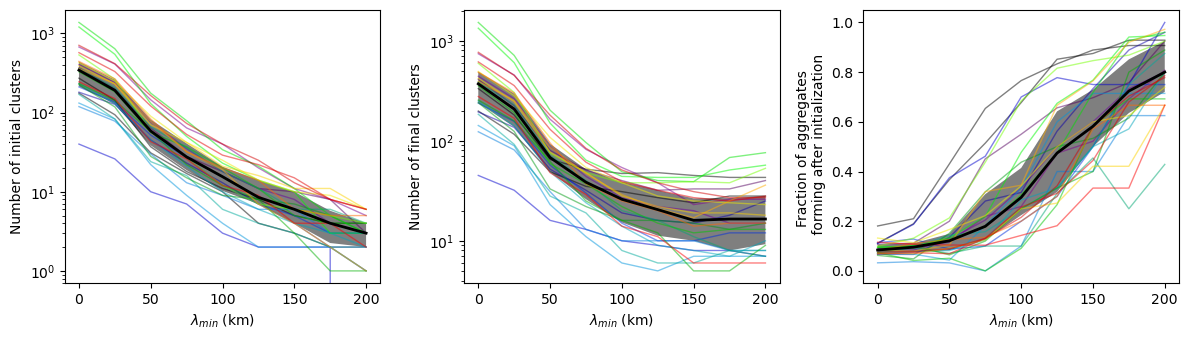

In [156]:
fig,axs = plt.subplots(1,3,figsize=(12,3.5))

# n_cc_init vs. lambda_min
ax = axs[0]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_initial_clusters',"Number of initial clusters",
              yscale='log')

# n_cc_final vs. lambda_min
ax = axs[1]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_final_clusters',"Number of final clusters",
              yscale='log')

# n_cc_final/n_cc_init vs. lambda_min
ax = axs[2]
# subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_final_clusters',"Multiplication factor",y_denominator='n_initial_clusters',
#               yscale='log')
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_initial_clusters',"Fraction of aggregates \n forming after initialization",y_denominator='n_final_clusters',
              one_minus=True,yscale='linear')

plt.tight_layout()


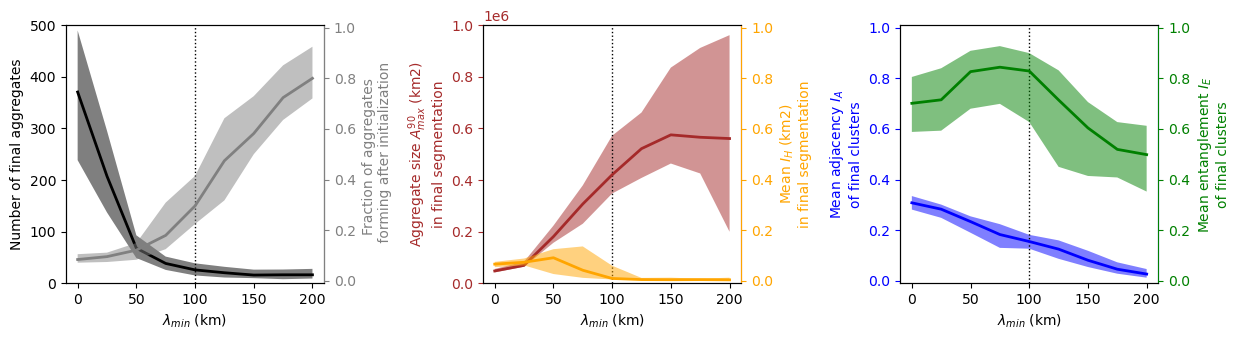

In [164]:
# fig,axs = plt.subplots(1,2,figsize=(8,3.5))
fig,axs = plt.subplots(1,3,figsize=(12.5,3.5))

#-- (a) number
ax = axs[0]

# reference line
ax.axvline(x=100,linewidth=1,linestyle=':',c='k')

# number
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_final_clusters',"Number of final aggregates",
              yscale='linear',show_all_cases=False)
ax.set_ylim((0,500))

# fraction formed after initialization
ax_doubled = ax.twinx()
color_diag = 'grey'
subplotAllData(ax_doubled,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_initial_clusters',"Fraction of aggregates \n forming after initialization",y_denominator='n_final_clusters',
              one_minus=True,yscale='linear',col_diag=color_diag,col_ylabel=color_diag,
              linestyle='--',show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,1.01))

#-- (b) size and heterogeneity
ax = axs[1]

# reference line
ax.axvline(x=100,linewidth=1,linestyle=':',c='k')

# size
diag = 'Amax_p90_km2'
label_diag = r"Aggregate size $A_{max}^{90}$ (km2)" "\n" "in final segmentation"
color_diag = 'brown'
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)',diag,
               label_diag,col_diag=color_diag,col_ylabel=color_diag,yscale='linear',show_all_cases=False)
ax.spines['right'].set_color(color_diag)
ax.tick_params(axis='y', colors=color_diag)
ax.set_ylim((0,1e6))

# Heterogeneity index
ax_doubled = ax.twinx()
color_diag = 'orange'
# subplotAllData(ax_doubled,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','initial_Amax_p90_minus_p10_km2',
#                r"Mean $I_H$ (km2)" "\n" "at initialization",y_denominator='initial_Amax_p90_km2',
#                y_denominator_mean='initial_Amax_p10_km2',
#                col_diag=color_diag,col_ylabel=color_diag,
#                one_minus=False,yscale='linear',show_all_cases=False)
subplotAllData(ax_doubled,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','Amax_p90_minus_p10_km2',
               r"Mean $I_H$ (km2)" "\n" "in final segmentation",y_denominator='Amax_p90_km2',
               # y_denominator_mean='Amax_p10_km2',
               one_minus=True,
               col_diag=color_diag,col_ylabel=color_diag,
               yscale='linear',show_all_cases=False)
# subplotAllData(ax_doubled,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','Amax_p90_km2',
#                r"Mean $I_H$ (km2)" "\n" "in final segmentation",y_denominator='Amax_p10_km2',
#                # y_denominator_mean='Amax_p10_km2',
#                # one_minus=True,
#                exp_transform=True,
#                col_diag=color_diag,col_ylabel=color_diag,
#                yscale='linear',show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,1.01))

#-- (c) quality metrics
ax = axs[2]

# reference line
ax.axvline(x=100,linewidth=1,linestyle=':',c='k')

# Adjacency
color_diag = 'blue'
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','IA5',
               r"Mean adjacency $I_A$" "\n" "of final clusters",col_diag=color_diag,col_ylabel=color_diag,
               show_all_cases=False)
ax.spines['right'].set_color(color_diag)
ax.tick_params(axis='y', colors=color_diag)
ax.set_ylim((-0.01,1.01))

# Entanglement
ax_doubled = ax.twinx()
color_diag = 'green'
# subplotAllData(ax_doubled,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)',
#                'INIT_IE5',r"Mean entanglement $I_E$" "\n" "of initial clusters",
#                col_diag=color_diag,col_ylabel=color_diag,show_all_cases=False)
subplotAllData(ax_doubled,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)',
               'IE5',r"Mean entanglement $I_E$" "\n" "of final clusters",
               col_diag=color_diag,col_ylabel=color_diag,show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,1.01))

plt.tight_layout()


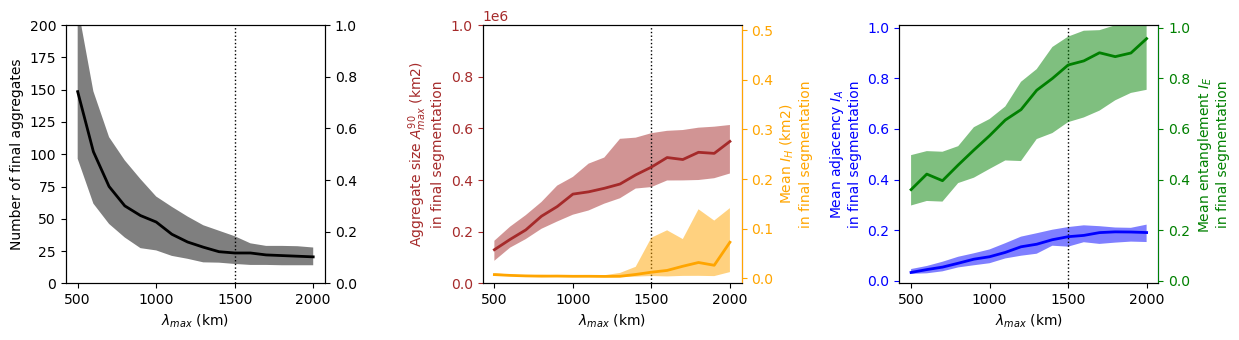

In [156]:
# fig,axs = plt.subplots(1,2,figsize=(8,3.5))
fig,axs = plt.subplots(1,3,figsize=(12.5,3.5))

#-- (a) number
ax = axs[0]

# reference line
ax.axvline(x=1500,linewidth=1,linestyle=':',c='k')

# number
subplotAllData(ax,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (km)','n_cc',"Number of final aggregates",
              yscale='linear',show_all_cases=False)
ax.set_ylim((0,200))
# fraction formed after initialization
ax_doubled = ax.twinx()
color_diag = 'grey'
# subplotAllData(ax_doubled,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (km)','n_initial_clusters',"Fraction of aggregates \n forming after initialization",y_denominator='n_final_clusters',
#               one_minus=True,yscale='linear',col_diag=color_diag,col_ylabel=color_diag,
#               linestyle='--',show_all_cases=False)
# ax_doubled.spines['right'].set_color(color_diag)
# ax_doubled.tick_params(axis='y', colors=color_diag)
# ax_doubled.set_ylim((-0.01,1.01))

#-- (b) size and heterogeneity
ax = axs[1]

# reference line
ax.axvline(x=1500,linewidth=1,linestyle=':',c='k')

# size
diag = 'Amax_p90_km2'
label_diag = r"Aggregate size $A_{max}^{90}$ (km2)" "\n" "in final segmentation"
color_diag = 'brown'
subplotAllData(ax,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (km)',diag,
               label_diag,col_diag=color_diag,col_ylabel=color_diag,yscale='linear',show_all_cases=False)
ax.spines['right'].set_color(color_diag)
ax.tick_params(axis='y', colors=color_diag)
ax.set_ylim((0,1e6))

# Heterogeneity index
ax_doubled = ax.twinx()
diag = 'Amax_p90_minus_p10_km2'
diag_normalize = 'Amax_p90_km2'
label_diag = r"Mean $I_H$ (km2)" "\n" "in final segmentation"
color_diag = 'orange'
subplotAllData(ax_doubled,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (km)',diag,
               label_diag,y_denominator=diag_normalize,
               # y_denominator_mean='Amax_p10_km2',
               one_minus=True,
               col_diag=color_diag,col_ylabel=color_diag,
               yscale='linear',show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,0.51))

#-- (c) quality metrics
ax = axs[2]

# reference line
ax.axvline(x=1500,linewidth=1,linestyle=':',c='k')

# Adjacency
color_diag = 'blue'
subplotAllData(ax,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (km)','IA5',
               r"Mean adjacency $I_A$" "\n" "in final segmentation",col_diag=color_diag,col_ylabel=color_diag,
               show_all_cases=False)
ax.spines['right'].set_color(color_diag)
ax.tick_params(axis='y', colors=color_diag)
ax.set_ylim((-0.01,1.01))

# Entanglement
ax_doubled = ax.twinx()
color_diag = 'green'
subplotAllData(ax_doubled,data_lambda_max,'lambda_max_km',r'$\lambda_{max}$ (km)',
               'IE5',r"Mean entanglement $I_E$" "\n" "in final segmentation",
               col_diag=color_diag,col_ylabel=color_diag,show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,1.01))

plt.tight_layout()


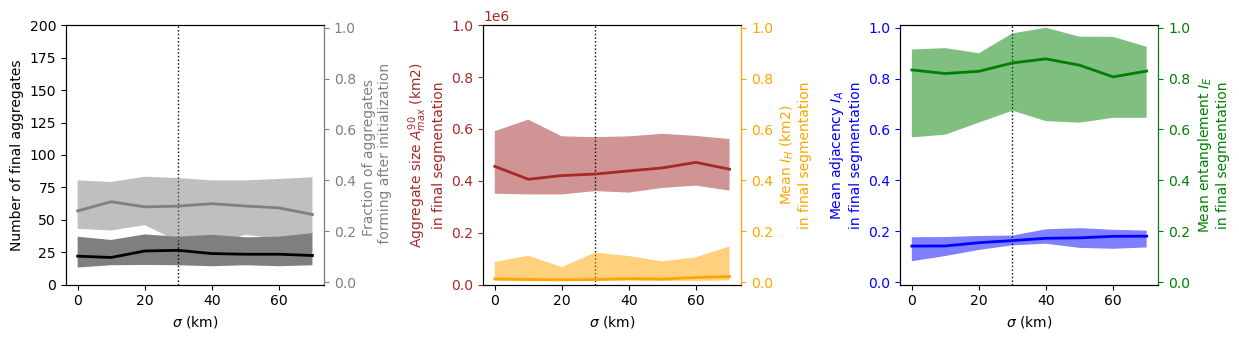

In [170]:
# fig,axs = plt.subplots(1,2,figsize=(8,3.5))
fig,axs = plt.subplots(1,3,figsize=(12.5,3.5))

#-- (a) number
ax = axs[0]

# reference line
ax.axvline(x=30,linewidth=1,linestyle=':',c='k')

# number
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','final_n_cc',"Number of final aggregates",
              yscale='linear',show_all_cases=False)
ax.set_ylim((0,200))
# fraction formed after initialization
ax_doubled = ax.twinx()
color_diag = 'grey'
subplotAllData(ax_doubled,data_sigma,'sigma_km',r'$\sigma$ (km)','n_initial_clusters',
               "Fraction of aggregates \n forming after initialization",y_denominator='final_n_cc',
              one_minus=True,yscale='linear',col_diag=color_diag,col_ylabel=color_diag,
              linestyle='--',show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,1.01))

#-- (b) size and heterogeneity
ax = axs[1]

# reference line
ax.axvline(x=30,linewidth=1,linestyle=':',c='k')

# size
color_diag = 'brown'
# subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','initial_Amax_p10_km2',
#                r"Aggregate size $A_{max}^{90}$ (km2)" "\n" "at initialization",
#                col_diag=color_diag,col_ylabel=color_diag,yscale='linear',show_all_cases=False)
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','final_Amax_p90_km2',
               r"Aggregate size $A_{max}^{90}$ (km2)" "\n" "in final segmentation",
               col_diag=color_diag,col_ylabel=color_diag,yscale='linear',show_all_cases=False)
ax.spines['right'].set_color(color_diag)
ax.tick_params(axis='y', colors=color_diag)
ax.set_ylim((0,1e6))

# Heterogeneity index
ax_doubled = ax.twinx()
color_diag = 'orange'
# subplotAllData(ax_doubled,data_sigma,'sigma_km',r'$\sigma$ (km)','initial_Amax_p90_minus_p10_km2',
#                r"Mean $I_H$ (km2)" "\n" "at initialization",y_denominator='initial_Amax_p90_km2',
#                # y_denominator_mean='initial_Amax_p10_km2',
#                one_minus=True,
#                col_diag=color_diag,col_ylabel=color_diag,
#                yscale='linear',show_all_cases=False)
subplotAllData(ax_doubled,data_sigma,'sigma_km',r'$\sigma$ (km)','final_Amax_p90_minus_p10_km2',
               r"Mean $I_H$ (km2)" "\n" "in final segmentation",y_denominator='final_Amax_p90_km2',
               # y_denominator_mean='final_Amax_p10_km2',
               one_minus=True,
               col_diag=color_diag,col_ylabel=color_diag,
               yscale='linear',show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,1.01))

#-- (c) quality metrics
ax = axs[2]

# reference line
ax.axvline(x=30,linewidth=1,linestyle=':',c='k')

# Adjacency
color_diag = 'blue'
subplotAllData(ax,data_sigma,'sigma_km',r'$\sigma$ (km)','IA5',
               r"Mean adjacency $I_A$" "\n" "in final segmentation",col_diag=color_diag,col_ylabel=color_diag,
               show_all_cases=False)
ax.spines['right'].set_color(color_diag)
ax.tick_params(axis='y', colors=color_diag)
ax.set_ylim((-0.01,1.01))

# Entanglement
ax_doubled = ax.twinx()
color_diag = 'green'
# subplotAllData(ax_doubled,data_sigma,'sigma_km',r'$\sigma$ (km)',
#                'INIT_IE5',r"Mean entanglement $I_E$" "\n" "at initialization",
#                col_diag=color_diag,col_ylabel=color_diag,show_all_cases=False)
subplotAllData(ax_doubled,data_sigma,'sigma_km',r'$\sigma$ (km)',
               'IE5',r"Mean entanglement $I_E$" "\n" "in final segmentation",
               col_diag=color_diag,col_ylabel=color_diag,show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,1.01))

plt.tight_layout()


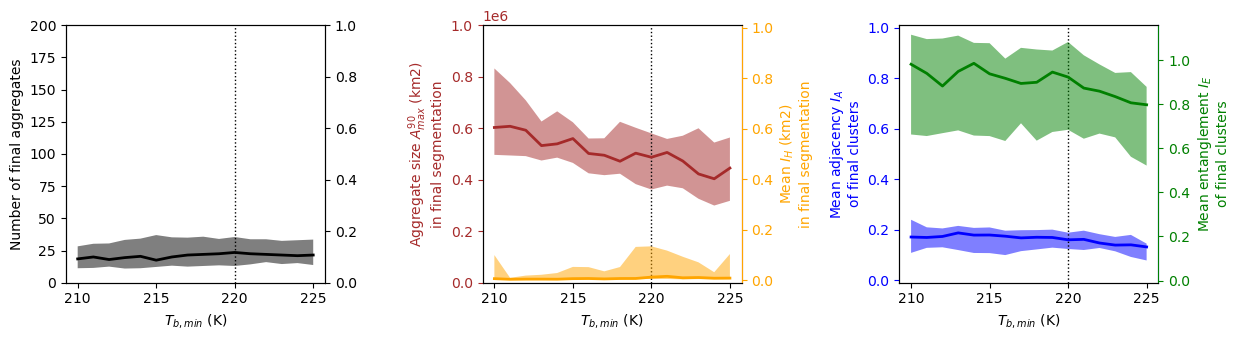

In [155]:
# fig,axs = plt.subplots(1,2,figsize=(8,3.5))
fig,axs = plt.subplots(1,3,figsize=(12.5,3.5))

#-- (a) number
ax = axs[0]

# reference line
ax.axvline(x=220,linewidth=1,linestyle=':',c='k')

# number
subplotAllData(ax,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)','n_cc',"Number of final aggregates",
              yscale='linear',show_all_cases=False)
ax.set_ylim((0,200))
# fraction formed after initialization
ax_doubled = ax.twinx()
color_diag = 'grey'
# subplotAllData(ax_doubled,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)','n_initial_clusters',
#                "Fraction of aggregates \n forming after initialization",y_denominator='final_n_cc',
#               one_minus=True,yscale='linear',col_diag=color_diag,col_ylabel=color_diag,
#               linestyle='--',show_all_cases=False)
# ax_doubled.spines['right'].set_color(color_diag)
# ax_doubled.tick_params(axis='y', colors=color_diag)
# ax_doubled.set_ylim((-0.01,1.01))

#-- (b) size and heterogeneity
ax = axs[1]

# reference line
ax.axvline(x=220,linewidth=1,linestyle=':',c='k')

# size
diag = 'Amax_p90_km2'
label_diag = r"Aggregate size $A_{max}^{90}$ (km2)" "\n" "in final segmentation"
color_diag = 'brown'
subplotAllData(ax,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)',diag,
               label_diag,col_diag=color_diag,col_ylabel=color_diag,yscale='linear',show_all_cases=False)
ax.spines['right'].set_color(color_diag)
ax.tick_params(axis='y', colors=color_diag)
ax.set_ylim((0,1e6))

# Heterogeneity index
ax_doubled = ax.twinx()
color_diag = 'orange'
# subplotAllData(ax_doubled,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)','initial_Amax_p90_minus_p10_km2',
#                r"Mean $I_H$ (km2)" "\n" "at initialization",y_denominator='initial_Amax_p90_km2',
#                y_denominator_mean='initial_Amax_p10_km2',
#                col_diag=color_diag,col_ylabel=color_diag,
#                one_minus=False,yscale='linear',show_all_cases=False)
subplotAllData(ax_doubled,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)','Amax_p90_minus_p10_km2',
               r"Mean $I_H$ (km2)" "\n" "in final segmentation",y_denominator='Amax_p90_km2',
               # y_denominator_mean='Amax_p10_km2',
               one_minus=True,
               col_diag=color_diag,col_ylabel=color_diag,
               yscale='linear',show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,1.01))

#-- (c) quality metrics
ax = axs[2]

# reference line
ax.axvline(x=220,linewidth=1,linestyle=':',c='k')

# Adjacency
color_diag = 'blue'
subplotAllData(ax,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)','IA5',
               r"Mean adjacency $I_A$" "\n" "of final clusters",col_diag=color_diag,col_ylabel=color_diag,
               show_all_cases=False)
ax.spines['right'].set_color(color_diag)
ax.tick_params(axis='y', colors=color_diag)
ax.set_ylim((-0.01,1.01))

# Entanglement
ax_doubled = ax.twinx()
color_diag = 'green'
# subplotAllData(ax_doubled,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)',
#                'INIT_IE5',r"Mean entanglement $I_E$" "\n" "of initial clusters",
#                col_diag=color_diag,col_ylabel=color_diag,show_all_cases=False)
subplotAllData(ax_doubled,data_Tbmin,'Tb_seed_K',r'$T_{b,min}$ (K)',
               'IE5',r"Mean entanglement $I_E$" "\n" "of final clusters",
               col_diag=color_diag,col_ylabel=color_diag,show_all_cases=False)
ax_doubled.spines['right'].set_color(color_diag)
ax_doubled.tick_params(axis='y', colors=color_diag)
ax_doubled.set_ylim((-0.01,1.16))

plt.tight_layout()


In [ ]:
fig,axs = plt.subplots(1,3,figsize=(12,3.5))

# n_cc_init vs. lambda_min
ax = axs[0]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_initial_clusters',"Number of initial clusters",
              yscale='log')

# n_cc_final vs. lambda_min
ax = axs[1]
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_final_clusters',"Number of final clusters",
              yscale='log')

# n_cc_final/n_cc_init vs. lambda_min
ax = axs[2]
# subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_final_clusters',"Multiplication factor",y_denominator='n_initial_clusters',
#               yscale='log')
subplotAllData(ax,data_lambda_min,'lambda_min_km',r'$\lambda_{min}$ (km)','n_initial_clusters',"Fraction of aggregates \n forming after initialization",y_denominator='n_final_clusters',
              one_minus=True,yscale='linear')

plt.tight_layout()
